# Vortex shedding behind a cylinder: the time-dependent Navier-Stokes equations

We solve the incompressible Navier-Stokes equations

$$u_t + (u\cdot\nabla) u - \nu\,\Delta u + \nabla p = 0, \qquad \nabla\cdot u = 0,$$

in the channel of `example14`, $(0, 2.2) \times (0, 0.41)$ with a cylinder of radius $0.05$ at $(0.2, 0.2)$ removed, with the same boundary conditions but a faster inflow, $U = 1.5$. The mean inflow velocity is $\bar U = 1$ and the Reynolds number $Re = \bar U D/\nu = 100$. This is the benchmark 2D-2 of M. Schäfer and S. Turek (1996). At this Reynolds number the flow does not settle to a steady state. Vortices leave the cylinder alternately from the top and the bottom, the von Kármán vortex street, and the lift on the cylinder oscillates.

We start from the steady Stokes flow, the solution without the convection term and without $u_t$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import dot, grad, div, inner, dx

**Mesh and spaces.** As in `example14`, with a somewhat coarser mesh so that the computation takes a few minutes: Taylor-Hood elements, $P_2$ for the velocity with the inflow profile and no slip built in, and $P_1$ for the pressure.

3860 triangles, 17051 unknowns


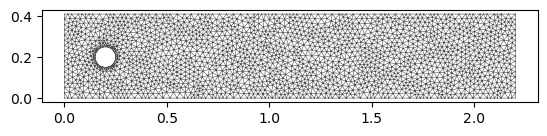

In [2]:
H = 0.41
m = fd.triangulate([(0, 0), (2.2, 0), (2.2, H), (0, H)], holes=[fd.circle(0.2, 0.2, 0.05, 40)],
                   edge_markers=[1, 2, 3, 4], max_edge=0.035, min_angle=28, smooth=20)

x, y = fd.x, fd.y
inflow = (4 * 1.5 * y * (H - y) / H**2, 0.0)
V = fd.VectorFunctionSpace(m, 2, dirichlet={4: inflow, 1: (0, 0), 3: (0, 0), 5: (0, 0)})
Q = fd.LagrangeSpace(m, 1)
W = fd.ProductSpace(V, Q)
print(m.ntriangles, "triangles,", W.dim, "unknowns")

m.plot()
plt.show()

## The time discretization

With the velocity and the pressure as one unknown $w = (u, p)$, the equations are a system of ordinary differential equations with a singular mass matrix,

$$M w'(t) = f(w), \qquad (M w', (v, q)) = (u_t, v), \qquad (f(w), (v, q)) = -\nu\,(\nabla u, \nabla v) - \left((u\cdot\nabla) u, v\right) + (p, \nabla\cdot v) + (q, \nabla\cdot u).$$

The pressure has no time derivative, so this is a differential-algebraic system, and the divergence-free constraint $(q, \nabla\cdot u) = 0$ must hold at every stage. We solve it with the two-stage Radau IIA method, `fd.IRK(M, f, dt, "radau", 2)`. Radau IIA is L-stable and stiffly accurate, which is what such systems need, and has order 3. Each step solves the nonlinear equations of the two stages together by a simplified Newton method, with the Jacobian computed from the form symbolically. The unknown `w` is a Function of `W.unconstrained`, which carries the inflow data, and IRK keeps the data at every stage.

The initial state must satisfy the constraint and the boundary conditions. Starting from rest, with $u = 0$ inside and the inflow on the boundary, it does not, and Newton fails at the first step. So we start from the Stokes flow. We take $\Delta t = 0.02$.

In [3]:
nu, dt = 0.001, 0.02
(u, p), (v, q) = fd.TrialFunctions(W), fd.TestFunctions(W)

w = fd.Function(W.unconstrained)                       # (u, p), with the inflow data
stokes = (nu * inner(grad(u), grad(v)) - p * div(v) - q * div(u)) * dx
w.vector[:] = fd.solve(stokes, dot(fd.as_vector([0.0, 0.0]), v) * dx).vector

uw, pw = w
M = fd.form(dot(u, v) * dx)
f = fd.form((-nu * inner(grad(uw), grad(v)) - dot(dot(grad(uw), uw), v) + pw * div(v) + q * div(uw)) * dx)
irk = fd.IRK(M, f, dt, "radau", 2, tol=1e-10)     # the stage residual stalls at round-off near 1e-12

**Drag and lift.** As in `example14`, the forces on the cylinder are volume integrals against $\Phi = (\phi, 0)$ (drag) and $\Phi = (0, \phi)$ (lift), with $\phi = 1$ on the cylinder and $\phi = 0$ away from it. Now the momentum equation contains $u_t$. We approximate it from the last three steps by the second-order backward difference $\left(3u^{n+1} - 4u^n + u^{n-1}\right)/(2\Delta t)$, keeping the two previous steps in `w1` ($u^n$) and `w0` ($u^{n-1}$),

$$F = -\left[\left(u_t, \Phi\right) + \nu\,(\nabla u, \nabla\Phi) + \left((u\cdot\nabla) u, \Phi\right) - (p, \nabla\cdot\Phi)\right],$$

and $c_D = 2F_D/(\bar U^2 D) = 20 F_D$, $c_L = 20 F_L$.

**Velocity.** We keep the solution at a few times and plot the speed $|u|$. The vortices leave the cylinder with the period $T_p = D/(\bar U\,St) \approx 0.33$, so the solution at $t = 1, 2, 3, \dots$ is at nearly the same phase of the cycle and looks the same. We keep it at $t = 1$, while the shedding develops, and at $t = 4, 4.08, 4.16, 4.24$, about a quarter of a period apart, where the vortices can be seen moving downstream. The velocity is $P_2$, so we draw it on a sub-triangulation with 4 × 4 small triangles in each element (`refine=4`), which shows the quadratic polynomial of each element instead of a linear interpolation between its nodes.

In [4]:
w0 = fd.Function(W.unconstrained)          # u^{n-1}
w1 = fd.Function(W.unconstrained)          # u^n
u0, p0 = w0
u1, p1 = w1

r = fd.sqrt((x - 0.2)**2 + (y - 0.2)**2)
s = fd.min_value(1.0, fd.max_value(0.0, (r - 0.05) / 0.1))
phi = 1 - 3 * s**2 + 2 * s**3
ut = (1.5 * uw - 2 * u1 + 0.5 * u0) / dt
PhiD, PhiL = fd.as_vector([phi, 0.0]), fd.as_vector([0.0, phi])
drag = fd.form(-20 * (dot(ut, PhiD) + nu * inner(grad(uw), grad(PhiD)) + dot(dot(grad(uw), uw), PhiD)
                      - pw * div(PhiD)) * dx)
lift = fd.form(-20 * (dot(ut, PhiL) + nu * inner(grad(uw), grad(PhiL)) + dot(dot(grad(uw), uw), PhiL)
                      - pw * div(PhiL)) * dx)

**The time loop**, up to $t = 5$. Each step advances `w` by Radau IIA, computes the forces and keeps the two previous steps. This takes about five minutes on this mesh.

In [5]:
T = 5.0
times, cD, cL = [], [], []
snapshots = {}
w0.vector[:] = w.vector
w1.vector[:] = w.vector
for n in range(1, round(T / dt) + 1):
    w0.vector[:] = w1.vector
    w1.vector[:] = w.vector
    irk.step(w)
    times.append(n * dt)
    cD.append(drag.assemble())
    cL.append(lift.assemble())
    if n in (50, 200, 204, 208, 212):
        snapshots[n * dt] = w.vector.copy()

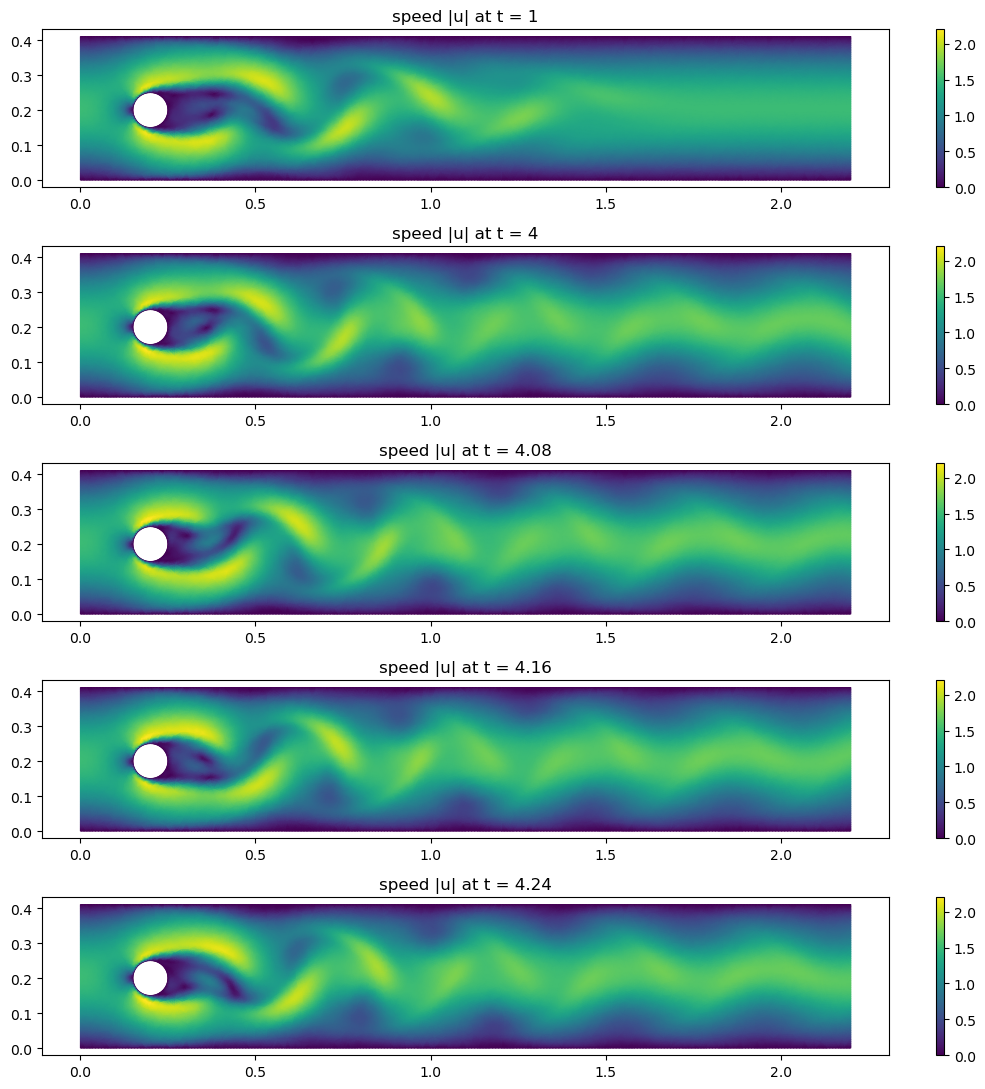

In [6]:
ws = fd.Function(W.unconstrained)           # to plot the kept solutions
fig, axs = plt.subplots(5, 1, figsize=(12, 11))
for ax, (t, coeffs) in zip(axs, snapshots.items()):
    ws.vector[:] = coeffs
    ws.split()[0].plot(ax, quiver=False, refine=4, cmap="viridis", vmin=0, vmax=2.2)
    ax.set_title(f"speed |u| at t = {t:g}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

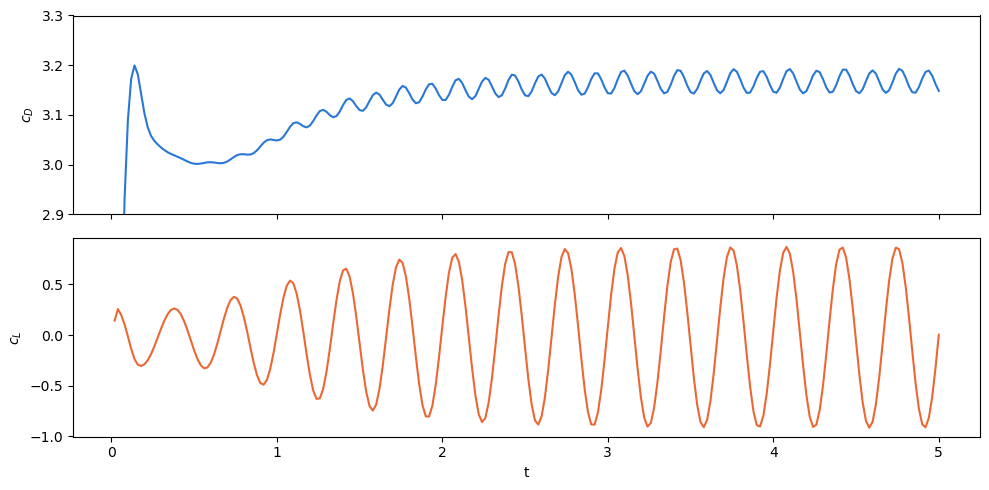

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axs[0].plot(times, cD, color="#2a78d6"); axs[0].set_ylabel("$c_D$")
axs[0].set_ylim(2.9, 3.3)                               # leave out the first steps
axs[1].plot(times, cL, color="#eb6834"); axs[1].set_ylabel("$c_L$"); axs[1].set_xlabel("t")
plt.tight_layout()
plt.show()

**The benchmark values.** Once the shedding is periodic, from about $t = 3$, we take the largest drag and lift coefficients and the Strouhal number $St = D/(\bar U\,T_p) = 0.1/T_p$, where $T_p$ is the period of the lift, measured between its upward zero crossings.

In [8]:
times, cD, cL = np.array(times), np.array(cD), np.array(cL)
late = times > 3
up = np.where((cL[late][:-1] < 0) & (cL[late][1:] >= 0))[0]
period = np.mean(np.diff(times[late][up]))
print(f"{'':>10} {'max c_D':>8} {'max c_L':>8} {'St':>7}")
print(f"{'FEMd':>10} {cD[late].max():8.3f} {cL[late].max():8.3f} {0.1 / period:7.3f}")
print(f"{'reference':>10} {'3.22-3.24':>8} {'0.99-1.01':>8} {'0.295-0.305':>7}")

            max c_D  max c_L      St
      FEMd    3.193    0.870   0.301
 reference 3.22-3.24 0.99-1.01 0.295-0.305


The Strouhal number falls within the range of Schäfer and Turek, and the drag and the lift oscillate with the right period. Their amplitudes are somewhat too small, $c_L$ by about 15 per cent, since the forces are set by the thin boundary layer on the cylinder, which this coarse mesh does not resolve well, and they still change with the time step. With $\Delta t = 0.01$ the run takes twice as long and gives $\max c_D = 3.189$ and $\max c_L = 0.874$. The values also depend strongly on the number of points on the cylinder. With 20 points the drag and the lift fall to about $2.9$ and $0.47$. For a sharper result use the finer mesh, `max_edge=0.02`, and a smaller step.